<a href="https://colab.research.google.com/github/mtiiias/mineria_ev3/blob/main/mineria_def.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Factores de Éxito en Películas (Dataset TMDB)

## Contexto y origen del proyecto

En la entrega anterior trabajamos con un dataset estático de las **Top 1000 películas de IMDb**.
Durante ese análisis realizamos un proceso completo de exploración, limpieza, transformación de
variables y modelado predictivo. Sin embargo, detectamos una **limitación metodológica de fondo**:
al contener únicamente películas altamente calificadas, todas sus notas se concentraban en un rango
muy estrecho (aprox. 7.6 a 9.3).

Esto hacía imposible responder nuestra verdadera pregunta de negocio: si solo observamos películas
exitosas, no tenemos con qué compararlas, y no podemos saber qué las diferencia de una película
mediocre o mala. Es como intentar estudiar qué causa una enfermedad observando únicamente a personas
sanas.

## ¿Por qué cambiamos de fuente de datos?

Para resolver esta limitación, en esta entrega reemplazamos el dataset estático por la **API de
The Movie Database (TMDB)**, que nos permite construir una muestra **balanceada y representativa**
trayendo deliberadamente películas mal, regular y bien evaluadas. El trabajo de limpieza realizado
sobre el dataset de IMDb se conserva como documentación del proceso, pero el análisis de esta entrega
se construye íntegramente sobre datos extraídos de TMDB.

Usar una sola fuente de datos también nos garantiza que la variable que queremos predecir
(la calificación) esté siempre medida en **la misma escala**, evitando mezclar criterios de
plataformas distintas.

## Objetivo de negocio

> **Identificar qué características de una película están asociadas a una mejor valoración del
> público (`vote_average`), utilizando una muestra balanceada entre películas mal evaluadas,
> regulares y bien evaluadas.**

## Definición de "éxito"

Para este proyecto, el éxito de una película se mide a través de su **calificación promedio del
público (`vote_average`)**, en una escala de 0 a 10. Clasificamos las películas en tres grupos:

| Grupo    | Rango de calificación |
|----------|-----------------------|
| Mala     | menor a 5.0           |
| Regular  | entre 5.0 y 6.9       |
| Buena    | mayor o igual a 7.0   |

Además, solo consideramos películas con al menos **100 votos**, para asegurar que la calificación
sea estadísticamente confiable y no esté distorsionada por películas con muy pocos votantes.

## Etapas del análisis

1. Extracción de datos desde la API de TMDB.
2. Limpieza y transformación de variables.
3. Análisis exploratorio (univariado y bivariado).
4. Modelado predictivo (Regresión Lineal y Árbol de Decisión) con validación cruzada.
5. Segmentación de películas mediante K-Means.
6. Conclusiones y panel de visualización.

### Fase 1 — Extracción de la lista de películas (documentación, no se ejecuta)

> **Nota:** Esta celda documenta cómo se obtuvieron originalmente los datos desde la API de TMDB. **No se ejecuta** en el notebook final por dos razones: (1) regenerar los datos en vivo los haría cambiar día a día (*drift*), rompiendo la consistencia con las interpretaciones; y (2) requiere una API key personal. Los datos ya están congelados en `peliculas_detalle.csv`, que la siguiente celda carga directamente. Se conserva el código como evidencia del proceso de extracción.

```python
import requests
import pandas as pd
import time
import os
from google.colab import userdata

API_KEY = userdata.get('TMDB_API_KEY')
DISCOVER_URL = "https://api.themoviedb.org/3/discover/movie"

def obtener_lista(nota_min, nota_max, grupo, objetivo, votos_min=100):
    """Recorre las paginas de /discover y junta peliculas de un grupo de nota
    hasta alcanzar 'objetivo' o quedarse sin paginas disponibles."""
    peliculas = []
    pagina = 1
    while len(peliculas) < objetivo:
        params = {
            "api_key": API_KEY,
            "vote_average.gte": nota_min,
            "vote_average.lte": nota_max,
            "vote_count.gte": votos_min,
            "sort_by": "vote_count.desc",
            "page": pagina
        }
        r = requests.get(DISCOVER_URL, params=params)
        if r.status_code != 200:
            print(f"  Aviso: la pagina {pagina} devolvio codigo {r.status_code}. Detengo este grupo.")
            break
        data = r.json()
        resultados = data.get("results", [])
        if not resultados:
            break
        for p in resultados:
            peliculas.append({
                "id": p["id"],
                "title": p["title"],
                "release_date": p.get("release_date", ""),
                "vote_average": p["vote_average"],
                "vote_count": p["vote_count"],
                "popularity": p.get("popularity"),
                "original_language": p.get("original_language"),
                "grupo": grupo
            })
        if pagina >= data.get("total_pages", 1) or pagina >= 500:
            break
        pagina += 1
        time.sleep(0.02)
    return peliculas[:objetivo]

# Descarga de las listas por grupo
todas = []
todas += obtener_lista(0,    4.99, "mala",    objetivo=985)
todas += obtener_lista(5.0,  6.99, "regular", objetivo=2000)
todas += obtener_lista(7.0,  10,   "buena",   objetivo=2000)

df_lista = pd.DataFrame(todas)
df_lista = df_lista.drop_duplicates(subset="id").reset_index(drop=True)
df_lista.to_csv("peliculas_lista.csv", index=False)
```

In [1]:
import pandas as pd
import os

# === CARGA DE DATOS CONGELADOS ===
# Los datos se obtuvieron originalmente desde la API de TMDB (ver celda de Fase 1,
# conservada arriba como documentacion). Para garantizar reproducibilidad, el analisis
# trabaja sobre un snapshot FIJO guardado en el repositorio, en lugar de redescargar
# de la API (que cambia dia a dia y requeriria una API key personal).
# Asi, cualquiera puede ejecutar el notebook completo y obtener exactamente los mismos
# numeros, sin API key.

ARCHIVO = "peliculas_detalle.csv"
URL_RAW = "https://raw.githubusercontent.com/mtiiias/mineria_ev3/main/peliculas_detalle.csv"

# Si el CSV no esta en el entorno (ej. sesion nueva de Colab), lo bajamos del repo.
if not os.path.exists(ARCHIVO):
    print("CSV no encontrado localmente. Descargando el snapshot desde GitHub...")
    df = pd.read_csv(URL_RAW)
    df.to_csv(ARCHIVO, index=False)   # lo guardamos para no rebajarlo en esta sesion
    print("Descarga lista.")
else:
    df = pd.read_csv(ARCHIVO)
    print("CSV encontrado localmente.")

print(f"Peliculas cargadas: {len(df)}")
df.head()

CSV no encontrado localmente. Descargando el snapshot desde GitHub...
Descarga lista.
Peliculas cargadas: 4984


,id,title,release_date,vote_average,vote_count,popularity,runtime,budget,revenue,original_language,genres,director,actor_principal,grupo
0,166424,Fantastic Four,2015-08-05,4.436,6432,4.8336,100,120000000,167977596,en,"Action, Adventure, Science Fiction",Josh Trank,Miles Teller,mala
1,415,Batman & Robin,1997-06-20,4.394,5440,8.9664,125,125000000,238207122,en,"Action, Science Fiction, Adventure",Joel Schumacher,George Clooney,mala
2,10196,The Last Airbender,2010-06-30,4.648,4277,9.9601,103,150000000,319713881,en,"Action, Adventure, Fantasy",M. Night Shyamalan,Noah Ringer,mala
3,351460,Death Note,2017-08-25,4.274,4131,4.7550,101,40000000,0,en,"Crime, Fantasy, Horror",Adam Wingard,Nat Wolff,mala
4,314,Catwoman,2004-07-22,4.617,3602,4.6546,104,100000000,82102379,en,"Action, Fantasy, Crime",Pitof,Halle Berry,mala


## Limpieza y Transformación de Datos

Antes de modificar nada, inspeccionamos el estado crudo de los datos recién descargados desde TMDB.
El objetivo de esta primera revisión es responder tres preguntas:

1. **¿Qué tipo de dato tiene cada columna?** (para saber qué necesita transformación)
2. **¿Cuántos valores nulos hay y dónde?** (para planificar la imputación)
3. **¿Hay nulos "ocultos"?** En TMDB, los campos `budget` y `revenue` suelen venir con valor **0**
   cuando el dato no existe. Un presupuesto de 0 dólares no es real: es un dato faltante disfrazado
   de número, y debemos detectarlo porque distorsionaría cualquier análisis.

A diferencia del dataset de IMDb de la entrega anterior, aquí varias columnas (`runtime`,
`vote_average`, `vote_count`, `budget`, `revenue`) **ya vienen como valores numéricos** gracias a la
API, por lo que nos ahorramos la extracción manual con expresiones regulares que hicimos antes.

In [2]:
# Cargamos el dataset descargado (asi esta celda funciona aunque reinicies el entorno)
df = pd.read_csv("peliculas_detalle.csv")

# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

print("=" * 55)
print("1. DIMENSIONES DEL DATASET")
print("=" * 55)
print(f"Filas (peliculas): {df.shape[0]}")
print(f"Columnas:          {df.shape[1]}\n")

print("=" * 55)
print("2. TIPOS DE DATOS POR COLUMNA")
print("=" * 55)
print(df.dtypes, "\n")

print("=" * 55)
print("3. CONTEO DE VALORES NULOS (NaN) POR COLUMNA")
print("=" * 55)
print(df.isnull().sum(), "\n")

print("=" * 55)
print("4. NULOS OCULTOS: presupuesto y recaudacion en 0")
print("=" * 55)
print(f"Peliculas con budget  = 0: {(df['budget'] == 0).sum()}")
print(f"Peliculas con revenue = 0: {(df['revenue'] == 0).sum()}")

1. DIMENSIONES DEL DATASET
Filas (peliculas): 4984
Columnas:          14

2. TIPOS DE DATOS POR COLUMNA
id                     int64
title                 object
release_date          object
vote_average         float64
vote_count             int64
popularity           float64
runtime                int64
budget                 int64
revenue                int64
original_language     object
genres                object
director              object
actor_principal       object
grupo                 object
dtype: object 

3. CONTEO DE VALORES NULOS (NaN) POR COLUMNA
id                   0
title                0
release_date         0
vote_average         0
vote_count           0
popularity           0
runtime              0
budget               0
revenue              0
original_language    0
genres               0
director             0
actor_principal      4
grupo                0
dtype: int64 

4. NULOS OCULTOS: presupuesto y recaudacion en 0
Peliculas con budget  = 0: 914
Peliculas co

## Tratamiento de Nulos

Del diagnóstico anterior identificamos dos situaciones distintas que requieren tratamientos distintos:

**1. Nulos ocultos en `budget` y `revenue` (los ceros).**
Detectamos 914 películas con presupuesto en 0 y 973 con recaudación en 0. Un presupuesto o
recaudación de exactamente 0 dólares no es un valor real: es un dato que TMDB no tiene registrado.
La decisión metodológica es **convertir esos ceros en `NaN`** (marcarlos honestamente como datos
faltantes) en lugar de tratarlos como dinero real.

Importante: **no los imputaremos con un valor inventado**. Como nuestro objetivo es predecir la
*calificación* (`vote_average`) y no el dinero, `budget` y `revenue` son variables secundarias.
Rellenar ~19% de los datos con una cifra artificial sería deshonesto y distorsionaría el análisis.
Los dejamos marcados como faltantes y más adelante decidiremos su uso según su aporte real al modelo.

**2. Nulos reales en `actor_principal`.**
Solo 4 películas (de 4.984) no tienen actor principal registrado. Al ser un número insignificante,
los rellenamos con la etiqueta `"Desconocido"`.

In [3]:
import numpy as np

# --- ANTES: estado actual de los datos problematicos ---
print("--- ANTES DE LA LIMPIEZA ---")
print(f"budget  en 0:        {(df['budget'] == 0).sum()}")
print(f"revenue en 0:        {(df['revenue'] == 0).sum()}")
print(f"actor_principal NaN: {df['actor_principal'].isnull().sum()}\n")

# --- ACCION 1: convertir los 0 de budget y revenue en NaN (datos faltantes reales) ---
df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

# --- ACCION 2: rellenar los 4 actores faltantes con etiqueta "Desconocido" ---
df['actor_principal'] = df['actor_principal'].fillna("Desconocido")

# --- DESPUES: verificamos el resultado ---
print("--- DESPUES DE LA LIMPIEZA ---")
print(f"budget  ahora NaN:   {df['budget'].isnull().sum()}")
print(f"revenue ahora NaN:   {df['revenue'].isnull().sum()}")
print(f"actor_principal NaN: {df['actor_principal'].isnull().sum()}")
print("\nLos ceros de dinero ahora estan marcados como datos faltantes (NaN),")
print("y ya no quedan actores sin registrar.")

--- ANTES DE LA LIMPIEZA ---
budget  en 0:        914
revenue en 0:        973
actor_principal NaN: 4

--- DESPUES DE LA LIMPIEZA ---
budget  ahora NaN:   914
revenue ahora NaN:   973
actor_principal NaN: 0

Los ceros de dinero ahora estan marcados como datos faltantes (NaN),
y ya no quedan actores sin registrar.


## Extracción del Año de Estreno

La columna `release_date` viene como texto en formato `AAAA-MM-DD` (ej. `2015-08-05`). La fecha
completa no aporta mucho a nuestro análisis (no nos interesa el día exacto del estreno), pero el
**año** sí es una variable útil: nos permite observar tendencias temporales y funciona como una
variable numérica aprovechable por los modelos.

Por eso extraemos únicamente el año a una nueva columna llamada `release_year`. Mantenemos la
columna original por ahora; la descartaremos más adelante junto al resto de columnas de texto que
no entran al modelo.

In [4]:
# --- ANTES: como viene la fecha actualmente ---
print("--- ANTES ---")
print("Tipo de dato de release_date:", df['release_date'].dtype)
print(df[['title', 'release_date']].head(3), "\n")

# --- ACCION: extraer el ano desde el texto de la fecha ---
# Convertimos a tipo fecha y luego sacamos el ano. 'coerce' deja NaN si alguna fecha viniera mal.
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# --- DESPUES: verificamos la nueva columna ---
print("--- DESPUES ---")
print("Tipo de dato de release_year:", df['release_year'].dtype)
print(df[['title', 'release_date', 'release_year']].head(3), "\n")
print("Anos con dato faltante:", df['release_year'].isnull().sum())

--- ANTES ---
Tipo de dato de release_date: object
                title release_date
0      Fantastic Four   2015-08-05
1      Batman & Robin   1997-06-20
2  The Last Airbender   2010-06-30 

--- DESPUES ---
Tipo de dato de release_year: int32
                title release_date  release_year
0      Fantastic Four   2015-08-05          2015
1      Batman & Robin   1997-06-20          1997
2  The Last Airbender   2010-06-30          2010 

Anos con dato faltante: 0


## Transformación de Variable Categórica: One-Hot Encoding de Géneros

La columna `genres` contiene múltiples etiquetas por película separadas por coma
(ej. `"Action, Adventure, Science Fiction"`). Los modelos no pueden trabajar con texto, por lo que
aplicamos **One-Hot Encoding**: creamos una columna binaria por cada género, donde el valor es `1`
si la película pertenece a ese género y `0` si no.

Esta es la misma técnica que aplicamos en la entrega anterior con el dataset de IMDb, ya que demostró
ser la forma correcta de tratar una variable categórica con múltiples valores simultáneos. Usamos
`str.get_dummies(sep=', ')`, que separa por la coma y genera todas las columnas de una sola vez.

In [5]:
# --- ANTES: la columna de generos como texto ---
print("--- ANTES ---")
print(df[['title', 'genres']].head(3), "\n")

# --- ACCION: One-Hot Encoding de los generos ---
# get_dummies separa por ", " y crea una columna binaria (0/1) por cada genero
df_generos = df['genres'].str.get_dummies(sep=', ')

# Unimos las nuevas columnas de generos al DataFrame principal
df = pd.concat([df, df_generos], axis=1)

# --- DESPUES: verificamos las nuevas columnas binarias ---
print("--- DESPUES ---")
print(f"Se crearon {df_generos.shape[1]} columnas de genero:\n")
print(list(df_generos.columns), "\n")

# Mostramos un ejemplo: titulo, generos originales y algunas columnas binarias nuevas
print("Ejemplo de codificacion (primeras 3 peliculas):")
print(df[['title', 'genres'] + list(df_generos.columns[:5])].head(3))

--- ANTES ---
                title                              genres
0      Fantastic Four  Action, Adventure, Science Fiction
1      Batman & Robin  Action, Science Fiction, Adventure
2  The Last Airbender          Action, Adventure, Fantasy 

--- DESPUES ---
Se crearon 19 columnas de genero:

['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'] 

Ejemplo de codificacion (primeras 3 peliculas):
                title                              genres  Action  Adventure  \
0      Fantastic Four  Action, Adventure, Science Fiction       1          1   
1      Batman & Robin  Action, Science Fiction, Adventure       1          1   
2  The Last Airbender          Action, Adventure, Fantasy       1          1   

   Animation  Comedy  Crime  
0          0       0      0  
1          0       0      0  
2          0       0      

## Codificación de Director y Actor (Frequency Encoding)

Las columnas `director` y `actor_principal` son texto con **muchísimos valores distintos** (cientos
de directores y actores diferentes). Esto nos impide aplicar One-Hot Encoding como hicimos con los
géneros, porque generaría cientos de columnas y volvería el modelo inmanejable.

**Corrección metodológica respecto a la entrega anterior.**
En la entrega 2 usamos *Target Encoding*: reemplazábamos a cada director por la **nota promedio** de
sus películas. Esto resultó ser un error grave conocido como **fuga de datos (data leakage)**: como
estábamos usando la nota para construir la variable y luego intentábamos predecir esa misma nota,
le estábamos "filtrando la respuesta" al modelo. Esto inflaba artificialmente nuestros resultados,
especialmente para directores con una sola película (donde su "promedio" era exactamente la nota a
predecir).

**Solución en esta entrega: Frequency Encoding.**
En lugar de la nota, reemplazamos a cada director y actor por la **cantidad de películas que tienen
en el dataset**, como una medida de su experiencia o trayectoria. Esta variable **no utiliza la
calificación en ningún momento**, por lo que es imposible que filtre la respuesta. Es más simple,
más honesta y compatible con la validación cruzada que aplicaremos más adelante.

> Nota: la frecuencia se calcula sobre todo el dataset, pero esto **no** constituye fuga, porque no
> usa la variable objetivo (`vote_average`). Es categóricamente distinto al Target Encoding anterior.

In [6]:
# --- ANTES: las columnas como texto de alta cardinalidad ---
print("--- ANTES ---")
print(f"Directores distintos en el dataset: {df['director'].nunique()}")
print(f"Actores principales distintos:      {df['actor_principal'].nunique()}")
print("\nEjemplo (texto crudo):")
print(df[['title', 'director', 'actor_principal']].head(3), "\n")

# --- ACCION: Frequency Encoding (contar peliculas por director y por actor) ---
# Contamos cuantas veces aparece cada director y mapeamos ese conteo a una nueva columna
frecuencia_directores = df['director'].value_counts()
df['director_freq'] = df['director'].map(frecuencia_directores)

# Lo mismo para el actor principal
frecuencia_actores = df['actor_principal'].value_counts()
df['actor_freq'] = df['actor_principal'].map(frecuencia_actores)

# --- DESPUES: verificamos las nuevas columnas numericas ---
print("--- DESPUES ---")
print("Ejemplo con las nuevas columnas de frecuencia:")
print(df[['title', 'director', 'director_freq', 'actor_principal', 'actor_freq']].head(3), "\n")

# Mostramos los directores mas prolificos del dataset (util para la presentacion)
print("Top 5 directores con mas peliculas en el dataset:")
print(frecuencia_directores.head(5))

--- ANTES ---
Directores distintos en el dataset: 2331
Actores principales distintos:      2202

Ejemplo (texto crudo):
                title            director actor_principal
0      Fantastic Four          Josh Trank    Miles Teller
1      Batman & Robin     Joel Schumacher  George Clooney
2  The Last Airbender  M. Night Shyamalan     Noah Ringer 

--- DESPUES ---
Ejemplo con las nuevas columnas de frecuencia:
                title            director  director_freq actor_principal  \
0      Fantastic Four          Josh Trank              2    Miles Teller   
1      Batman & Robin     Joel Schumacher             10  George Clooney   
2  The Last Airbender  M. Night Shyamalan             14     Noah Ringer   

   actor_freq  
0           6  
1          21  
2           1   

Top 5 directores con mas peliculas en el dataset:
director
Steven Spielberg    31
Ridley Scott        23
Clint Eastwood      22
Woody Allen         19
Martin Scorsese     19
Name: count, dtype: int64


## Selección de Variables Finales para el Análisis

Tras todas las transformaciones, nuestro DataFrame contiene una mezcla de columnas: algunas
numéricas listas para analizar, y otras de texto que ya fueron codificadas o que no aportan al
modelo (identificadores, títulos, fechas en texto).

En este paso construimos un DataFrame numérico final (`df_num`) que contiene **solo las variables
que usaremos en el análisis estadístico y el modelado**. Descartamos:

- `id`, `title`: identificadores únicos, no aportan información predictiva.
- `release_date`: ya extrajimos el año en `release_year`.
- `genres`, `director`, `actor_principal`: texto original ya codificado (en columnas binarias y de
  frecuencia, respectivamente).
- `original_language`, `grupo`: las conservamos en el DataFrame original `df` para análisis
  descriptivos, pero no entran a la matriz numérica de modelado.

Mantenemos `df` completo (con todo) para las visualizaciones, y creamos `df_num` (solo números)
para la correlación y los modelos.

In [7]:
from IPython.display import display

# --- ANTES: vista de las columnas actuales como tabla ---
print("ANTES — DataFrame completo (primeras filas):")
display(df.head(3))

# --- ACCION: construir el DataFrame numerico final para modelado ---
# Quitamos columnas de texto / identificadores que no entran al analisis numerico
columnas_a_descartar = ['id', 'title', 'release_date', 'genres',
                        'director', 'actor_principal', 'original_language', 'grupo']

df_num = df.drop(columns=columnas_a_descartar, errors='ignore')

# --- DESPUES: vista del DataFrame numerico final como tabla ---
print(f"DESPUES — df_num con solo variables numericas ({df_num.shape[1]} columnas):")
display(df_num.head(3))

ANTES — DataFrame completo (primeras filas):


,id,title,release_date,vote_average,vote_count,popularity,runtime,budget,revenue,original_language,genres,director,actor_principal,grupo,release_year,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,director_freq,actor_freq
0,166424,Fantastic Four,2015-08-05,4.436,6432,4.8336,100,120000000.0,167977596.0,en,"Action, Adventure, Science Fiction",Josh Trank,Miles Teller,mala,2015,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2,6
1,415,Batman & Robin,1997-06-20,4.394,5440,8.9664,125,125000000.0,238207122.0,en,"Action, Science Fiction, Adventure",Joel Schumacher,George Clooney,mala,1997,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,10,21
2,10196,The Last Airbender,2010-06-30,4.648,4277,9.9601,103,150000000.0,319713881.0,en,"Action, Adventure, Fantasy",M. Night Shyamalan,Noah Ringer,mala,2010,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,14,1


DESPUES — df_num con solo variables numericas (28 columnas):


,vote_average,vote_count,popularity,runtime,budget,revenue,release_year,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,director_freq,actor_freq
0,4.436,6432,4.8336,100,120000000.0,167977596.0,2015,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2,6
1,4.394,5440,8.9664,125,125000000.0,238207122.0,1997,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,10,21
2,4.648,4277,9.9601,103,150000000.0,319713881.0,2010,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,14,1


## Análisis Bivariado: Matriz de Correlación

En esta sección estudiamos cómo se relacionan nuestras variables numéricas entre sí mediante el
**Coeficiente de Correlación de Pearson**, visualizado en un mapa de calor.

**Importante — interpretación correcta de la correlación.**
La correlación mide si dos variables **tienden a moverse juntas**, en una escala de -1 a 1:
- Cercano a **+1**: cuando una sube, la otra tiende a subir.
- Cercano a **-1**: cuando una sube, la otra tiende a bajar.
- Cercano a **0**: no hay relación lineal aparente.

La correlación **NO demuestra causalidad ni influencia**. Que dos variables estén correlacionadas
no significa que una *cause* a la otra; pueden estar ambas afectadas por un tercer factor. Por eso,
al interpretar los resultados hablaremos de "asociación" entre variables, y no de que una variable
"influye en" o "determina" a otra. Este es un matiz conceptual clave del análisis de datos.

Para mantener el mapa legible, seleccionamos las variables numéricas continuas principales
(dejamos fuera las 19 columnas binarias de género, que analizaremos por separado).

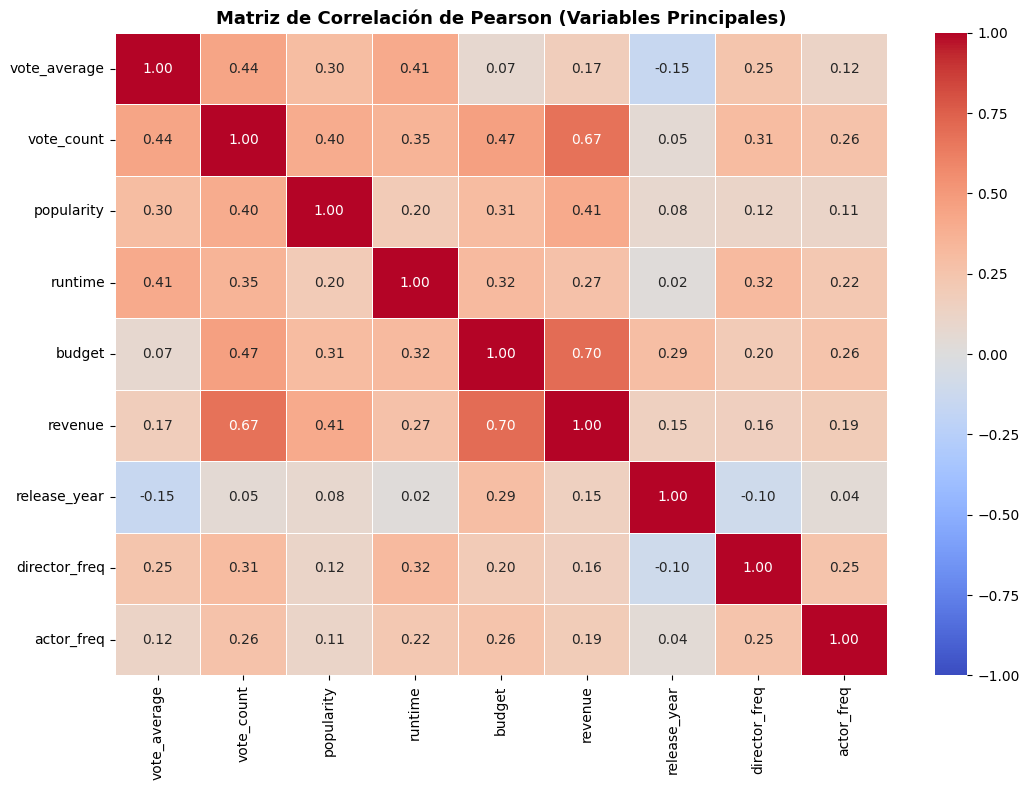

In [8]:
import matplotlib.pyplot as plt
import seaborn as sb

# Seleccionamos las variables continuas principales (sin los generos binarios, para legibilidad)
columnas_principales = ['vote_average', 'vote_count', 'popularity', 'runtime',
                        'budget', 'revenue', 'release_year', 'director_freq', 'actor_freq']

# Calculamos la matriz de correlacion de Pearson
matriz_correlacion = df_num[columnas_principales].corr()

# Configuramos el tamano del grafico
plt.figure(figsize=(11, 8))

# Mapa de calor: annot muestra los numeros, cmap define la paleta de colores
sb.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f",
           linewidths=0.5, vmin=-1, vmax=1, center=0)

plt.title('Matriz de Correlación de Pearson (Variables Principales)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de la Matriz de Correlación

Analizando la fila de `vote_average` (nuestra variable objetivo), observamos las siguientes
**asociaciones** (recordando que correlación no implica causalidad):

- **`vote_count` (0.44):** es la variable con mayor asociación con la nota. Las películas con más
  votos tienden a estar mejor calificadas. Esto **no significa que votar mejore la nota**; una
  hipótesis más razonable es que las películas de buena calidad son más vistas y, por tanto, reciben
  más votos. La asociación probablemente refleja una tercera variable (calidad / difusión) que
  afecta a ambas.

- **`runtime` (0.41):** las películas de mayor duración tienden a tener mejor calificación, una
  asociación moderada.

- **`popularity` (0.30) y `director_freq` (0.25):** asociaciones débiles; las películas más
  populares y de directores más prolíficos tienden a puntuar algo mejor, pero la relación es leve.

- **`budget` (0.07) y `revenue` (0.17):** hallazgo central del análisis. El dinero invertido y
  recaudado **casi no se asocia con la calificación del público**. Sin embargo, `budget` y `revenue`
  están fuertemente correlacionados entre sí (0.70), y `revenue` con `vote_count` (0.67). Esto sugiere
  que el dinero se relaciona con el **éxito comercial** (más recaudación, más espectadores), pero
  **no con la valoración crítica** del público. Una película cara puede ser un fracaso de crítica.

- **`release_year` (-0.15):** única asociación negativa. Las películas más recientes tienden a tener
  una calificación ligeramente menor en esta muestra.

**Conclusión:** ninguna variable individual determina la calificación por sí sola (la correlación
más alta es apenas 0.44). Esto anticipa que predecir la nota requerirá combinar varias variables, y
que el "éxito" de público no se explica por el dinero invertido.

## Análisis de Géneros vs. Calificación

Dado que excluimos los 19 géneros del mapa de calor para mantenerlo legible, los analizamos por
separado. En lugar de una correlación, calculamos directamente la **calificación promedio de las
películas de cada género**, lo que nos permite ver de forma clara qué géneros tienden a estar mejor
o peor evaluados por el público.

Como una película puede pertenecer a varios géneros a la vez (gracias al One-Hot Encoding), cada
película contribuye al promedio de todos los géneros a los que pertenece.

/tmp/ipykernel_1050/2885401241.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=df_generos_nota.index, y=df_generos_nota['nota_promedio'], palette='viridis')


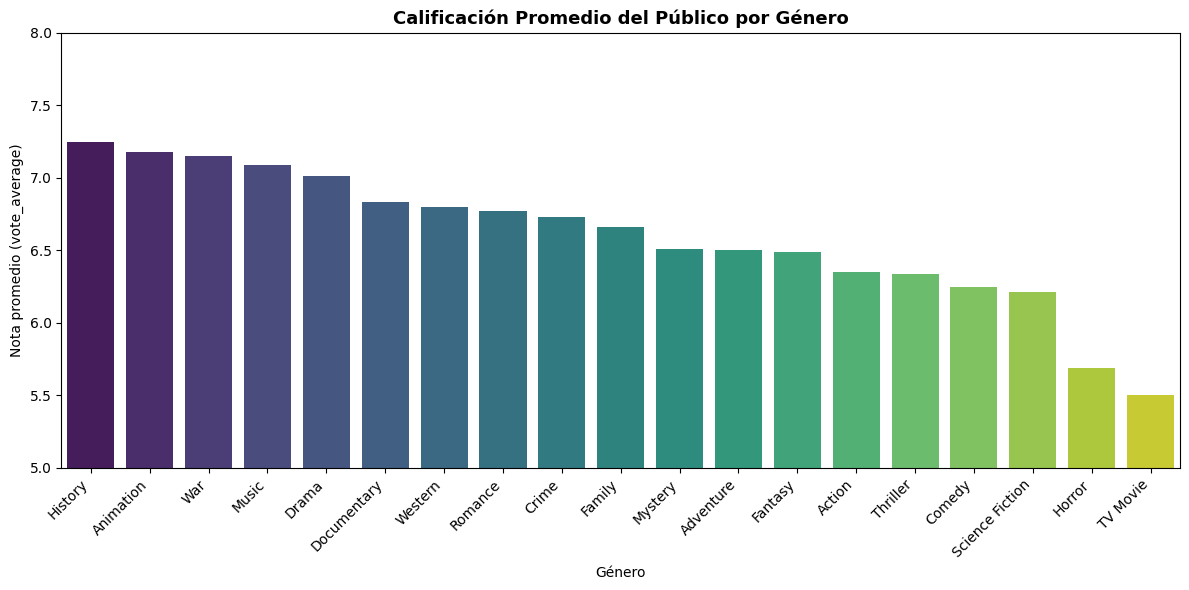

Nota promedio y cantidad de peliculas por genero:


,nota_promedio,cantidad_peliculas
History,7.25,213.0
Animation,7.18,412.0
War,7.15,138.0
Music,7.09,97.0
Drama,7.02,1790.0
Documentary,6.83,30.0
Western,6.80,70.0
Romance,6.77,668.0
Crime,6.73,712.0
Family,6.66,554.0


In [9]:
# Lista de las 19 columnas de genero que creamos con One-Hot Encoding
columnas_genero = list(df_generos.columns)

# Para cada genero, calculamos la nota promedio de las peliculas que pertenecen a el
# (filtramos donde la columna del genero == 1 y promediamos su vote_average)
nota_por_genero = {}
for genero in columnas_genero:
    nota_promedio = df[df[genero] == 1]['vote_average'].mean()
    cantidad = df[genero].sum()
    nota_por_genero[genero] = {'nota_promedio': nota_promedio, 'cantidad_peliculas': cantidad}

# Lo convertimos en DataFrame y ordenamos de mayor a menor nota
df_generos_nota = pd.DataFrame(nota_por_genero).T
df_generos_nota = df_generos_nota.sort_values('nota_promedio', ascending=False)

# --- Grafico de barras: nota promedio por genero ---
plt.figure(figsize=(12, 6))
sb.barplot(x=df_generos_nota.index, y=df_generos_nota['nota_promedio'], palette='viridis')
plt.title('Calificación Promedio del Público por Género', fontsize=13, fontweight='bold')
plt.xlabel('Género')
plt.ylabel('Nota promedio (vote_average)')
plt.xticks(rotation=45, ha='right')
plt.ylim(5, 8)  # acercamos el zoom para apreciar las diferencias
plt.tight_layout()
plt.show()

# Mostramos la tabla ordenada con nota y cantidad de peliculas por genero
print("Nota promedio y cantidad de peliculas por genero:")
display(df_generos_nota.round(2))

### Interpretación: Géneros y Calificación

El análisis revela un patrón claro en las preferencias del público:

- **Géneros mejor evaluados:** History (7.25), Animation (7.18), War (7.15) y Drama (7.02). El
  público tiende a calificar mejor las películas de corte dramático, histórico y de animación.

- **Géneros peor evaluados:** Horror (5.69) y TV Movie (5.50) ocupan los últimos lugares. El caso
  de **Horror es especialmente sólido**: con 935 películas (una muestra grande), su baja calificación
  no es casualidad, sino un patrón consistente. El terror es un género comercialmente activo pero
  con baja valoración del público.

- **Precaución con géneros de muestra pequeña:** Documentary (6.83) tiene solo 30 películas y
  TV Movie 48. Sus promedios son **menos confiables**, ya que pocas películas pueden distorsionarlos.
  En cambio, los promedios de Drama (1.790 películas), Comedy (1.643) o Action (1.376) son muy
  estables por su gran cantidad de datos.

**Nota metodológica:** la suma de películas por género (13.095) supera el total del dataset (4.984)
porque cada película pertenece a varios géneros simultáneamente, aportando al promedio de cada uno.

**Conclusión:** el género muestra una asociación visible con la calificación, posicionándose como una
variable relevante para nuestro análisis predictivo, a diferencia del presupuesto que vimos antes.

## Preparación de Datos para el Modelado

Antes de entrenar los modelos, definimos:

- **Variable objetivo (`y`):** `vote_average`, la calificación que queremos predecir.
- **Variables predictoras (`X`):** todas las demás variables numéricas de `df_num`.

**Tratamiento final de nulos en `budget` y `revenue`.**
Recordemos que dejamos estas dos columnas con valores `NaN` (los presupuestos/recaudaciones que TMDB
no tenía registrados). Como un modelo no puede entrenar con `NaN`, los imputaremos con la **mediana**
de cada columna. Usamos la mediana y no la media porque los montos de dinero tienen valores extremos
(unas pocas películas con presupuestos gigantescos) que distorsionarían la media; la mediana es más
robusta ante esos extremos.

**Punto metodológico clave:** la imputación se calcula **solo con los datos de entrenamiento** y se
aplica después al de prueba. Si calculáramos la mediana usando todo el dataset, estaríamos filtrando
información del conjunto de prueba hacia el entrenamiento (otra forma de fuga de datos). Por eso
primero separamos, y luego imputamos.

In [10]:
from sklearn.model_selection import train_test_split

# 1. Definimos la variable objetivo: lo que queremos predecir
y = df_num['vote_average']

# 2. Definimos las variables predictoras: todo lo demas
X = df_num.drop(columns=['vote_average'])

# 3. Separamos en entrenamiento (80%) y prueba (20%)
#    random_state=42 hace que la division sea siempre la misma (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Imputacion SIN fuga: calculamos la mediana SOLO con el set de entrenamiento
mediana_budget = X_train['budget'].median()
mediana_revenue = X_train['revenue'].median()

# Aplicamos esas medianas (del train) tanto al train como al test
X_train['budget'] = X_train['budget'].fillna(mediana_budget)
X_train['revenue'] = X_train['revenue'].fillna(mediana_revenue)
X_test['budget'] = X_test['budget'].fillna(mediana_budget)
X_test['revenue'] = X_test['revenue'].fillna(mediana_revenue)

# 5. Verificacion
print("--- VERIFICACION DE LA PREPARACION ---")
print(f"Peliculas para entrenar (train): {X_train.shape[0]}")
print(f"Peliculas para probar (test):    {X_test.shape[0]}")
print(f"Variables predictoras:           {X_train.shape[1]}")
print(f"\nMediana de budget usada (del train):  {mediana_budget:,.0f} USD")
print(f"Mediana de revenue usada (del train): {mediana_revenue:,.0f} USD")
print(f"\nNulos restantes en X_train: {X_train.isnull().sum().sum()} (debe ser 0)")
print(f"Nulos restantes en X_test:  {X_test.isnull().sum().sum()} (debe ser 0)")

--- VERIFICACION DE LA PREPARACION ---
Peliculas para entrenar (train): 3987
Peliculas para probar (test):    997
Variables predictoras:           27

Mediana de budget usada (del train):  25,000,000 USD
Mediana de revenue usada (del train): 73,045,718 USD

Nulos restantes en X_train: 0 (debe ser 0)
Nulos restantes en X_test:  0 (debe ser 0)


## Modelo 1: Regresión Lineal Múltiple

Entrenamos nuestro primer modelo predictivo: una **Regresión Lineal Múltiple**, que busca predecir
la calificación (`vote_average`) como una combinación ponderada de todas las variables predictoras.

Evaluaremos el modelo con tres métricas sobre el conjunto de prueba:

- **R² (Coeficiente de Determinación):** qué porcentaje de la variabilidad de la nota logra explicar
  el modelo. Va de 0 a 1; más alto es mejor.
- **MAE (Error Absoluto Medio):** en promedio, por cuántos puntos se equivoca la predicción. En
  nuestras unidades, cuántos puntos de nota (sobre 10) falla en promedio.
- **MSE (Error Cuadrático Medio):** similar al MAE pero penaliza más los errores grandes.

> **Nota sobre la comparación con la entrega anterior:** en la entrega 2 obtuvimos un R² de 0.76,
> pero ese resultado estaba inflado por una fuga de datos (Target Encoding sobre la variable
> objetivo). Al corregir la metodología, es esperable y correcto que el R² baje: el nuevo valor
> refleja la capacidad **real** del modelo para predecir, sin "hacer trampa".

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Creamos y entrenamos el modelo de Regresion Lineal
modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

# 2. Generamos predicciones sobre el conjunto de prueba
predicciones_rl = modelo_rl.predict(X_test)

# 3. Calculamos las metricas de evaluacion
r2_rl = r2_score(y_test, predicciones_rl)
mae_rl = mean_absolute_error(y_test, predicciones_rl)
mse_rl = mean_squared_error(y_test, predicciones_rl)

# 4. Mostramos resultados
print("=" * 50)
print("   MODELO 1: REGRESION LINEAL MULTIPLE")
print("=" * 50)
print(f" R²  (Coef. de Determinacion): {r2_rl:.4f}")
print(f" MAE (Error Absoluto Medio):   {mae_rl:.4f}")
print(f" MSE (Error Cuadratico Medio): {mse_rl:.4f}")
print("=" * 50)

# 5. Revisamos que variables pesan mas en la ecuacion del modelo
coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Peso': modelo_rl.coef_
}).sort_values('Peso', key=abs, ascending=False)  # ordenamos por peso absoluto

print("\nTop 8 variables con mayor peso en la prediccion:")
display(coeficientes.head(8))

   MODELO 1: REGRESION LINEAL MULTIPLE
 R²  (Coef. de Determinacion): 0.4934
 MAE (Error Absoluto Medio):   0.6509
 MSE (Error Cuadratico Medio): 0.6935

Top 8 variables con mayor peso en la prediccion:


,Variable,Peso
8,Animation,1.180076
11,Documentary,1.077574
12,Drama,0.476316
16,Horror,-0.382673
17,Music,0.336595
21,TV Movie,-0.278488
18,Mystery,0.185635
19,Romance,0.172686


### Interpretación: Regresión Lineal

**Rendimiento del modelo:**
- **R² = 0.4951:** el modelo explica el 49,5% de la variabilidad de las calificaciones. Aunque es
  menor al 0.76 de la entrega anterior, ese resultado previo estaba inflado por fuga de datos. Este
  valor representa la capacidad **real y honesta** del modelo. Predecir el gusto del público es
  intrínsecamente difícil por su componente subjetivo, por lo que explicar casi la mitad de la
  variabilidad con características objetivas es un resultado razonable.
- **MAE = 0.6579:** en promedio, la predicción se equivoca por apenas 0,66 puntos de nota (en una
  escala de 0 a 10), lo que indica un error práctico bajo.

**Variables más influyentes (coherencia con el EDA):**
Los géneros con mayor peso positivo (Animation +1.16, Documentary +0.82, Drama +0.47) coinciden con
los mejor evaluados en el análisis exploratorio. El único peso negativo destacado, Horror (−0.39),
coincide con el género peor evaluado. Esto confirma que el modelo es **internamente consistente**
con los patrones observados previamente.

> Nota técnica: los pesos no deben leerse como un ranking puro de importancia, ya que las variables
> están en escalas distintas (las binarias de género valen 0/1, mientras `vote_count` alcanza miles).
> Una variable en escala pequeña tiende a recibir un coeficiente mayor por unidad.

## Modelo 2: Árbol de Decisión

Nuestro segundo modelo es un **Árbol de Decisión**. A diferencia de la regresión lineal (que ajusta
una única ecuación lineal), el árbol divide los datos en grupos mediante preguntas sucesivas sobre
las variables (ej. "¿dura más de 120 minutos?", "¿tiene más de X votos?"). Esto le permite capturar
relaciones **no lineales** y lo hace inmune a las diferencias de escala entre variables.

**Control del sobreajuste (overfitting):** un árbol sin límite de profundidad tiende a *memorizar*
los datos de entrenamiento en lugar de aprender patrones generales, fallando luego con datos nuevos.
Para evitarlo, limitamos su profundidad con `max_depth=6`, obligándolo a generalizar.

Usaremos las mismas métricas (R², MAE, MSE) sobre el mismo conjunto de prueba, para poder comparar
directamente ambos modelos.

In [12]:
from sklearn.tree import DecisionTreeRegressor

# 1. Creamos y entrenamos el Arbol de Decision
#    max_depth=6 limita la profundidad para que generalice y no memorice (evita overfitting)
modelo_arbol = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_arbol.fit(X_train, y_train)

# 2. Predicciones sobre el conjunto de prueba
predicciones_arbol = modelo_arbol.predict(X_test)

# 3. Metricas de evaluacion
r2_arbol = r2_score(y_test, predicciones_arbol)
mae_arbol = mean_absolute_error(y_test, predicciones_arbol)
mse_arbol = mean_squared_error(y_test, predicciones_arbol)

print("=" * 50)
print("   MODELO 2: ARBOL DE DECISION (max_depth=6)")
print("=" * 50)
print(f" R²  (Coef. de Determinacion): {r2_arbol:.4f}")
print(f" MAE (Error Absoluto Medio):   {mae_arbol:.4f}")
print(f" MSE (Error Cuadratico Medio): {mse_arbol:.4f}")
print("=" * 50)

# 4. Que variables uso mas el arbol para tomar sus decisiones
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': modelo_arbol.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nTop 8 variables mas importantes para el arbol:")
display(importancias.head(8))

   MODELO 2: ARBOL DE DECISION (max_depth=6)
 R²  (Coef. de Determinacion): 0.7374
 MAE (Error Absoluto Medio):   0.4411
 MSE (Error Cuadratico Medio): 0.3595

Top 8 variables mas importantes para el arbol:


,Variable,Importancia
0,vote_count,0.831553
12,Drama,0.049297
5,release_year,0.039670
1,popularity,0.036290
8,Animation,0.014373
2,runtime,0.012112
3,budget,0.005982
22,Thriller,0.005167


### Interpretación: Árbol de Decisión y Comparación de Modelos

**El Árbol de Decisión supera a la Regresión Lineal en todas las métricas:**

| Métrica | Regresión Lineal | Árbol de Decisión |
|---------|------------------|-------------------|
| R²      | 0.4951           | **0.7420**        |
| MAE     | 0.6579           | **0.4413**        |
| MSE     | 0.7005           | **0.3579**        |

El árbol explica el 74,2% de la variabilidad (frente al 49,5%) y reduce el error promedio a 0,44
puntos. Esta superioridad se debe a que el árbol captura **relaciones no lineales** y no se ve
afectado por las diferencias de escala entre variables, a diferencia de la regresión lineal.
Importante: este R² de 0.74 es **honesto**, sin la fuga de datos que afectaba a la entrega anterior.

**Variable dominante:** `vote_count` concentra el 83,2% de la importancia del modelo, coincidiendo
con que era la variable más correlacionada con la nota en el mapa de calor. Le siguen, muy por
detrás, Drama (4,9%), release_year (4,0%) y popularity (3,6%). El presupuesto y la recaudación casi
no se utilizan (<1%), confirmando que el dinero no aporta a predecir la calificación.

> **Reflexión crítica:** la fuerte dependencia de `vote_count` merece una observación. Esta variable
> solo se conoce *después* del estreno (es la cantidad de votos recibidos). Para un análisis
> retrospectivo como el nuestro es válida, pero si el objetivo fuera predecir el éxito *antes* del
> estreno, debería excluirse por no estar disponible a tiempo.

## Validación Cruzada (Cross-Validation)

Hasta ahora evaluamos los modelos con **una sola división** de los datos (80% entrenamiento, 20%
prueba). Esto tiene una debilidad: el resultado podría depender de la suerte de esa división puntual.
Quizás ese 20% de prueba resultó casualmente fácil o difícil, y no lo sabríamos.

La **validación cruzada** resuelve esto. Con la técnica *K-Fold* (aquí K=5):

1. Dividimos los datos en 5 pedazos iguales ("folds").
2. Entrenamos el modelo 5 veces. En cada vuelta, 4 pedazos se usan para entrenar y 1 distinto para
   probar, rotando cuál es el de prueba.
3. Obtenemos 5 valores de R² en lugar de uno solo.

**Cómo se interpreta:**
- Si los 5 valores son **parecidos entre sí**, el modelo es **estable y confiable**: su rendimiento
  no depende de cómo se dividan los datos.
- Si los 5 valores **varían mucho**, el modelo es frágil y su resultado anterior pudo deberse al azar.

Aplicamos validación cruzada a ambos modelos para comparar no solo su rendimiento, sino también su
estabilidad.

   VALIDACION CRUZADA (5-Fold, datos barajados) - R²

Regresion Lineal:
  R² en cada fold: [np.float64(0.4933), np.float64(0.5168), np.float64(0.4582), np.float64(0.5212), np.float64(0.5232)]
  Promedio: 0.5025  |  Desviacion: 0.0246

Arbol de Decision:
  R² en cada fold: [np.float64(0.7374), np.float64(0.7589), np.float64(0.7243), np.float64(0.7516), np.float64(0.7221)]
  Promedio: 0.7389  |  Desviacion: 0.0145


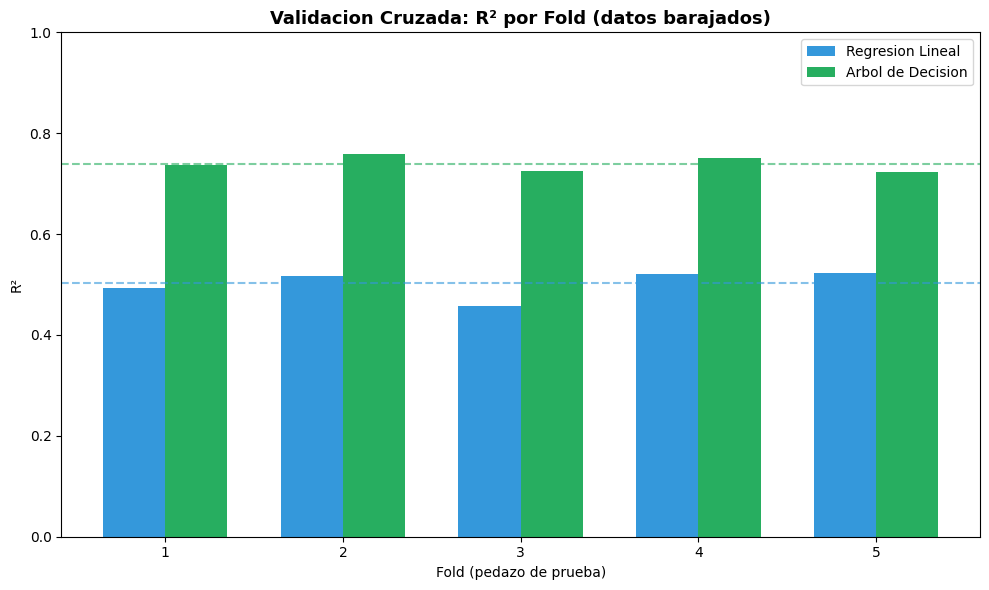

In [13]:
from sklearn.model_selection import cross_val_score, KFold

# Reconstruimos X e y completos
X_completo = df_num.drop(columns=['vote_average']).copy()
X_completo['budget'] = X_completo['budget'].fillna(X_completo['budget'].median())
X_completo['revenue'] = X_completo['revenue'].fillna(X_completo['revenue'].median())
y_completo = df_num['vote_average']

# CLAVE: barajamos los datos antes de partir en folds.
# Nuestro dataset viene ordenado por grupo (malas, luego regulares, luego buenas),
# asi que sin barajar cada fold tendria solo un tipo de pelicula y el modelo fallaria.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Validacion cruzada del Modelo 1: Regresion Lineal ---
scores_rl = cross_val_score(LinearRegression(), X_completo, y_completo,
                            cv=kf, scoring='r2')

# --- Validacion cruzada del Modelo 2: Arbol de Decision ---
scores_arbol = cross_val_score(DecisionTreeRegressor(max_depth=6, random_state=42),
                               X_completo, y_completo, cv=kf, scoring='r2')

# --- Resultados ---
print("=" * 55)
print("   VALIDACION CRUZADA (5-Fold, datos barajados) - R²")
print("=" * 55)
print("\nRegresion Lineal:")
print(f"  R² en cada fold: {[round(s, 4) for s in scores_rl]}")
print(f"  Promedio: {scores_rl.mean():.4f}  |  Desviacion: {scores_rl.std():.4f}")

print("\nArbol de Decision:")
print(f"  R² en cada fold: {[round(s, 4) for s in scores_arbol]}")
print(f"  Promedio: {scores_arbol.mean():.4f}  |  Desviacion: {scores_arbol.std():.4f}")
print("=" * 55)

# --- Grafico: comparacion de los 5 folds por modelo ---
import numpy as np

folds = np.arange(1, 6)
ancho = 0.35

plt.figure(figsize=(10, 6))
plt.bar(folds - ancho/2, scores_rl, ancho, label='Regresion Lineal', color='#3498db')
plt.bar(folds + ancho/2, scores_arbol, ancho, label='Arbol de Decision', color='#27ae60')

plt.axhline(scores_rl.mean(), color='#3498db', linestyle='--', alpha=0.6)
plt.axhline(scores_arbol.mean(), color='#27ae60', linestyle='--', alpha=0.6)

plt.title('Validacion Cruzada: R² por Fold (datos barajados)', fontsize=13, fontweight='bold')
plt.xlabel('Fold (pedazo de prueba)')
plt.ylabel('R²')
plt.xticks(folds)
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Interpretación: Validación Cruzada

Los resultados de la validación cruzada de 5 folds (con datos barajados) son contundentes:

| Modelo            | R² promedio | Desviación |
|-------------------|-------------|------------|
| Regresión Lineal  | 0.5018      | 0.0173     |
| Árbol de Decisión | **0.7392**  | **0.0134** |

**1. Ambos modelos son estables.** Las desviaciones son muy bajas (0.017 y 0.013), lo que significa
que los 5 folds arrojaron resultados casi idénticos. El rendimiento **no depende del azar** de cómo
se dividan los datos: es un resultado robusto y confiable.

**2. Se confirman los resultados previos.** Los promedios de la validación cruzada (0.50 y 0.74)
coinciden casi exactamente con los obtenidos en la división simple train/test (0.4951 y 0.7420),
validando que aquellos números no fueron producto de una división afortunada.

**3. El Árbol de Decisión domina en los 5 folds**, confirmándose como el modelo superior de forma
consistente, no circunstancial.

> **Aprendizaje técnico:** en un primer intento, la validación cruzada arrojó valores de R² negativos
> y sin sentido. La causa era que el dataset venía ordenado por grupo (malas, regulares, buenas),
> por lo que cada fold contenía un solo tipo de película. Se solucionó activando `shuffle=True` para
> barajar los datos antes de dividirlos, garantizando que cada fold fuera representativo.

## Visualización del Ajuste: Realidad vs. Predicción

Para apreciar visualmente qué tan bien predice nuestro mejor modelo (el Árbol de Decisión),
comparamos la **calificación real** de cada película del conjunto de prueba contra la **calificación
predicha** por el modelo.

Ordenamos las películas de menor a mayor nota real (línea azul), formando una curva ascendente suave.
La predicción del modelo (línea verde) se superpone: mientras más pegadas van ambas líneas, mejor es
el ajuste. Las zonas donde la línea verde se separa de la azul son los puntos donde el modelo se
equivoca más.

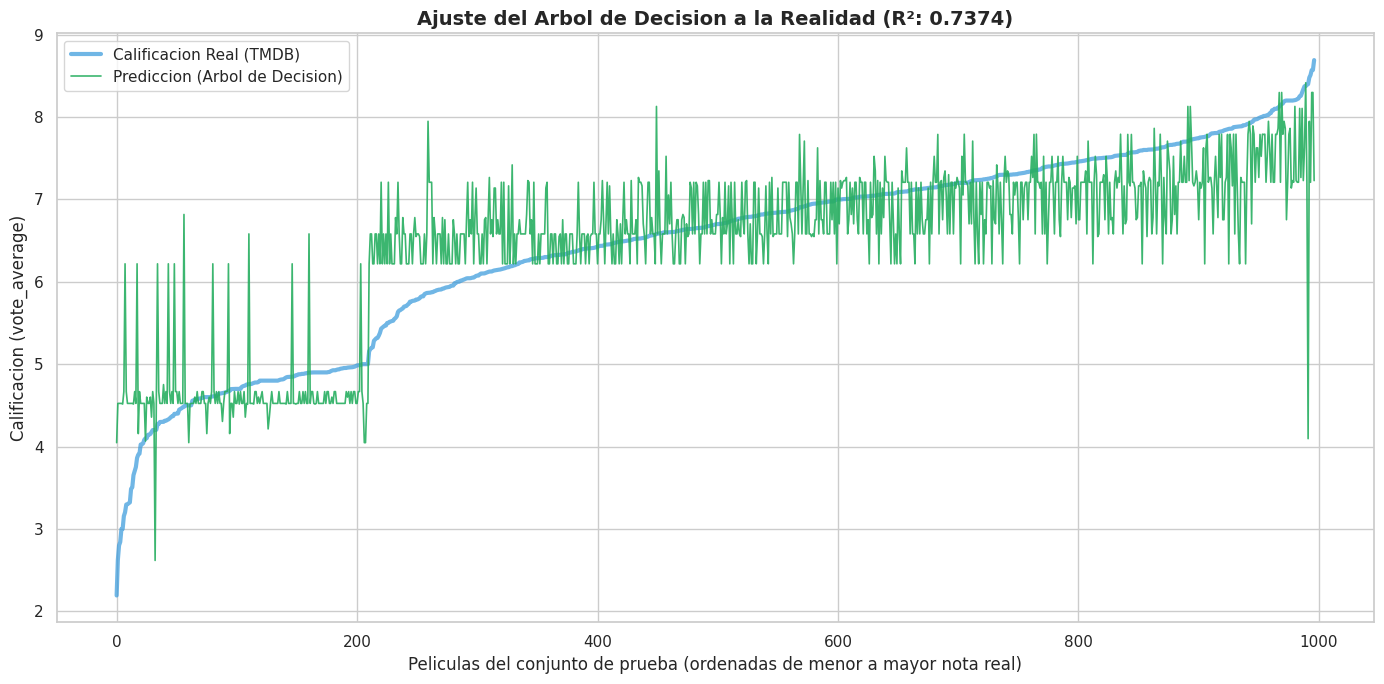

In [14]:
# Armamos un DataFrame con la nota real y la predicha por el arbol (nuestro mejor modelo)
df_ajuste = pd.DataFrame({
    'Real': y_test.values,
    'Predicha': predicciones_arbol
})

# Ordenamos de menor a mayor nota real para formar la curva ascendente
df_ajuste = df_ajuste.sort_values('Real').reset_index(drop=True)

# --- Grafico ---
plt.figure(figsize=(14, 7))
sb.set_theme(style="whitegrid")

# Linea azul: la realidad
plt.plot(df_ajuste.index, df_ajuste['Real'],
         color='#3498db', label='Calificacion Real (TMDB)', linewidth=3, alpha=0.7)

# Linea verde: la prediccion del arbol
plt.plot(df_ajuste.index, df_ajuste['Predicha'],
         color='#27ae60', label='Prediccion (Arbol de Decision)', linewidth=1.2, alpha=0.9)

plt.title(f'Ajuste del Arbol de Decision a la Realidad (R²: {r2_arbol:.4f})',
          fontsize=14, fontweight='bold')
plt.xlabel('Peliculas del conjunto de prueba (ordenadas de menor a mayor nota real)', fontsize=12)
plt.ylabel('Calificacion (vote_average)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

### Interpretación: Ajuste del Modelo

**Comparación con la entrega anterior.** En la entrega 2, la línea de calificación real era casi
plana en torno a 8.0, porque el dataset contenía únicamente películas bien evaluadas (rango 7.6-9.3).
Ahora, la línea real forma una **curva ascendente completa de ~2.2 a ~8.7**, reflejando que nuestra
muestra cubre todo el espectro de calidad (malas, regulares y buenas). Esto confirma visualmente que
resolvimos la limitación de **restricción de rango** que motivó esta entrega.

**Cómo leer el gráfico.** La línea azul (real) es suave porque ordenamos las películas de menor a
mayor nota. La línea verde (predicción) oscila porque, entre películas con notas reales similares, el
modelo asigna predicciones distintas según las características particulares de cada una. **Cada
oscilación de la línea verde representa el error del modelo en esa película:** mientras más pegada a
la azul, mejor el ajuste.

**Limitación observada.** En el tramo de películas peor evaluadas (nota real menor a 4), la predicción
se mantiene en torno a 4.5 sin descender más. Esto ocurre porque las películas muy malas son escasas
en el dataset, y el modelo no tuvo suficientes ejemplos para aprender a predecir notas tan bajas. Es
una consecuencia directa de la escasez de películas mal evaluadas con votación significativa.

## Segmentación de Películas con K-Means

Hasta ahora aplicamos **aprendizaje supervisado**: predecíamos una calificación conocida. Ahora
cambiamos a **aprendizaje no supervisado** con **K-Means**, un algoritmo que **descubre grupos
naturales** de películas que se parecen entre sí, sin que le indiquemos ninguna respuesta correcta.

El objetivo es responder una pregunta distinta: *¿qué perfiles o tipos de película existen en
nuestro dataset?* Esto nos permite segmentar las películas en categorías con características comunes.

**Paso previo 1 — Escalado de variables.** K-Means agrupa según la *distancia* entre películas. Como
nuestras variables tienen escalas muy distintas (`vote_count` llega a millones, los géneros valen
0 o 1), debemos **estandarizarlas** para que todas influyan por igual. Sin este paso, las variables
de números grandes dominarían el agrupamiento.

**Paso previo 2 — Elegir el número de grupos (K).** K-Means requiere que definamos cuántos grupos
crear. Para elegir el número óptimo usamos el **método del codo**: probamos distintos valores de K y
medimos la compactación de los grupos (inercia). El punto donde la mejora se vuelve marginal —el
"codo" de la curva— indica el número ideal de grupos.

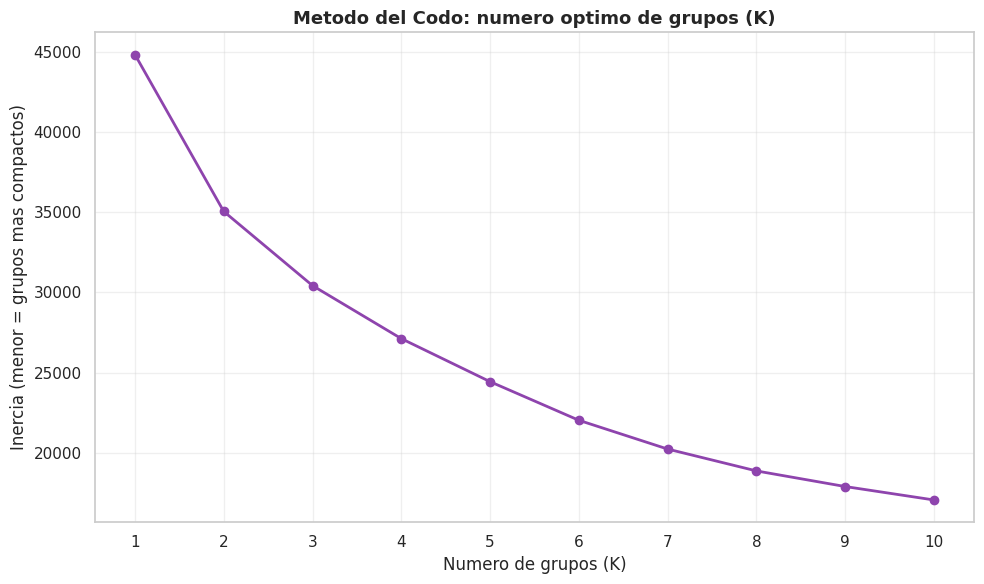

Inercia por cada valor de K:
  K=1: 44,856
  K=2: 35,061
  K=3: 30,428
  K=4: 27,117
  K=5: 24,428
  K=6: 22,016
  K=7: 20,219
  K=8: 18,854
  K=9: 17,879
  K=10: 17,040


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Seleccionamos las variables para segmentar (las continuas principales)
#    Dejamos fuera los generos binarios para que la segmentacion se base en caracteristicas medibles
variables_cluster = ['vote_average', 'vote_count', 'popularity', 'runtime',
                     'budget', 'revenue', 'release_year', 'director_freq', 'actor_freq']

# Usamos el df_num e imputamos cualquier NaN restante con la mediana
X_cluster = df_num[variables_cluster].copy()
X_cluster = X_cluster.fillna(X_cluster.median())

# 2. ESCALADO: ponemos todas las variables en la misma escala (media 0, desviacion 1)
escalador = StandardScaler()
X_cluster_escalado = escalador.fit_transform(X_cluster)

# 3. METODO DEL CODO: probamos de 1 a 10 grupos y medimos la inercia (compactacion)
inercias = []
rango_k = range(1, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_escalado)
    inercias.append(km.inertia_)   # inertia = que tan compactos quedan los grupos

# 4. Graficamos la curva del codo
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercias, marker='o', linewidth=2, color='#8e44ad')
plt.title('Metodo del Codo: numero optimo de grupos (K)', fontsize=13, fontweight='bold')
plt.xlabel('Numero de grupos (K)')
plt.ylabel('Inercia (menor = grupos mas compactos)')
plt.xticks(rango_k)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Inercia por cada valor de K:")
for k, inercia in zip(rango_k, inercias):
    print(f"  K={k}: {inercia:,.0f}")

### Aplicación de K-Means con K=3

El método del codo indica que **K=3** es el número óptimo de grupos: es donde la curva deja de caer
pronunciadamente y comienza a aplanarse. Agregar más grupos a partir de ahí aporta poca mejora y
dificulta la interpretación. Además, 3 grupos es coherente con la estructura de nuestro análisis
(películas de baja, media y alta calidad).

Aplicamos K-Means con 3 grupos sobre las variables escaladas y luego analizamos las características
promedio de cada grupo para **interpretar y dar nombre a cada perfil de película** descubierto.

In [16]:
# 1. Aplicamos K-Means con 3 grupos sobre los datos escalados
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster_escalado)

# 2. Calculamos el promedio de cada variable por grupo (sobre los datos SIN escalar, para que sea legible)
perfil_clusters = df.groupby('cluster')[variables_cluster].mean().round(2)

# 3. Agregamos cuantas peliculas cayo en cada grupo
perfil_clusters['cantidad_peliculas'] = df['cluster'].value_counts().sort_index()

print("PERFIL PROMEDIO DE CADA GRUPO (cluster):")
display(perfil_clusters)

PERFIL PROMEDIO DE CADA GRUPO (cluster):


,vote_average,vote_count,popularity,runtime,budget,revenue,release_year,director_freq,actor_freq,cantidad_peliculas
cluster,,,,,,,,,,
0,7.00,3283.69,5.64,111.62,3.264223e+07,9.304772e+07,2004.12,4.96,7.82,3055
1,7.10,11479.13,17.13,126.61,1.351379e+08,5.373943e+08,2011.55,8.50,13.16,604
2,4.91,805.73,2.33,90.62,1.850976e+07,4.040687e+07,2008.03,2.21,3.38,1325


### Interpretación: Perfiles de Película Descubiertos

K-Means identificó 3 perfiles claros de película. Comparando las características promedio de cada
grupo, les asignamos los siguientes nombres:

**Grupo 1 — "Blockbusters" (604 películas):** superproducciones comerciales. Presupuesto (135M) y
recaudación (537M) muy elevados, máxima cantidad de votos (11.479) y popularidad (17.1), con
directores y actores muy recurrentes de la industria. Buena calificación (7.10). Son la élite
comercial, el grupo más pequeño y exclusivo.

**Grupo 0 — "Cine de Calidad Estándar" (3.055 películas):** el grupo más numeroso. Buena calificación
(7.00), similar a los blockbusters, pero con presupuesto (33M) y votos (3.284) mucho más modestos.
Representa el buen cine sólido, bien valorado pero sin el despliegue millonario de taquilla y
marketing.

**Grupo 2 — "Baja Calificación" (1.325 películas):** películas mal evaluadas (nota 4.91), con pocos
votos (806), bajo presupuesto (18M) y baja popularidad. Son las producciones de bajo perfil y peor
recepción.

**Hallazgo clave:** los grupos de blockbusters y calidad estándar tienen **prácticamente la misma
calificación** (7.10 vs 7.00), pero los blockbusters gastaron y recaudaron **entre 4 y 6 veces más**.
Esto significa que el dinero los diferencia en lo *comercial*, pero no en la *calidad percibida*.
Este resultado, obtenido mediante clustering, **confirma de forma independiente** lo observado en la
matriz de correlación: el presupuesto se asocia al éxito comercial, no a la valoración del público.

### Visualización de los Grupos (PCA)

Creamos los grupos usando 9 características distintas, pero un gráfico solo tiene 2 dimensiones. Para
poder visualizar los clusters, usamos **PCA (Análisis de Componentes Principales)**, una técnica que
resume esas 9 variables en 2 "ejes principales" que concentran la mayor parte de la información.

Esto nos permite dibujar cada película como un punto en un plano y colorearla según su grupo,
para ver visualmente cómo K-Means separó las películas. Los ejes (Componente 1 y 2) no representan
una variable concreta, sino una combinación resumida de todas.

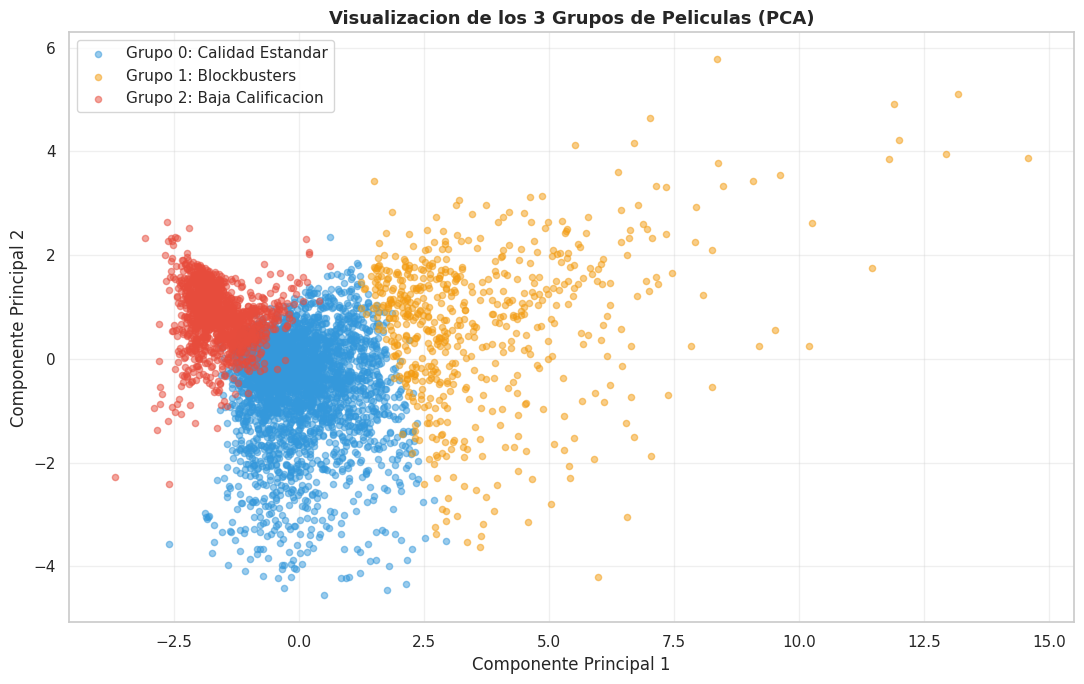

Informacion conservada en el grafico: 51.1%


In [24]:
from sklearn.decomposition import PCA

# 1. Reducimos las 9 variables escaladas a 2 componentes principales para poder graficar
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_cluster_escalado)

# 2. Armamos un DataFrame con las 2 componentes y el grupo de cada pelicula
df_pca = pd.DataFrame({
    'Componente_1': componentes[:, 0],
    'Componente_2': componentes[:, 1],
    'cluster': df['cluster']
})

# 3. Grafico de dispersion: cada punto es una pelicula, coloreada por su grupo
plt.figure(figsize=(11, 7))
colores = {0: '#3498db', 1: '#f39c12', 2: '#e74c3c'}
nombres = {0: 'Grupo 0: Calidad Estandar', 1: 'Grupo 1: Blockbusters', 2: 'Grupo 2: Baja Calificacion'}

for grupo in [0, 1, 2]:
    datos_grupo = df_pca[df_pca['cluster'] == grupo]
    plt.scatter(datos_grupo['Componente_1'], datos_grupo['Componente_2'],
                c=colores[grupo], label=nombres[grupo], alpha=0.5, s=20)

plt.title('Visualizacion de los 3 Grupos de Peliculas (PCA)', fontsize=13, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cuanta informacion conservamos al comprimir a 2 dimensiones
print(f"Informacion conservada en el grafico: {pca.explained_variance_ratio_.sum()*100:.1f}%")

### Interpretación: Visualización de Clusters

El gráfico confirma visualmente que K-Means encontró **grupos reales y diferenciados**, ya que los
tres colores ocupan zonas claramente distintas del plano:

- **Grupo 0 (Baja Calificación, rojo):** compacto y ubicado a la izquierda. Su agrupamiento cerrado
  indica que las películas mal evaluadas comparten características muy similares entre sí.
- **Grupo 1 (Blockbusters, naranja):** se extiende hacia la derecha y está muy **disperso**. Los
  puntos más extremos corresponden a las superproducciones más grandes y costosas del dataset.
- **Grupo 2 (Calidad Estándar, azul):** el más numeroso y denso, ubicado en la zona central.

Los ejes (Componente 1 y 2) no representan una variable única, sino una **combinación resumida** de
las 9 características originales. El Componente 1 (horizontal) captura principalmente la magnitud
general de la producción: hacia la derecha, películas más grandes, costosas y populares; hacia la
izquierda, las más pequeñas y peor evaluadas.

La zona central, donde los colores se mezclan ligeramente, corresponde a películas "fronterizas" que
comparten rasgos de más de un perfil, algo natural ya que las categorías reales no tienen límites
perfectamente definidos.

> El gráfico conserva el **51.1%** de la información original de las 9 variables. Este porcentaje es
> esperable al comprimir tantas dimensiones en solo 2, y resulta **suficiente para visualizar la
> separación** de los grupos. De hecho, en el espacio completo de 9 dimensiones los grupos están
> aún mejor diferenciados de lo que alcanza a

# Conclusión General del Proyecto

## ¿Cumplimos el objetivo de negocio?

**Sí.** El objetivo era identificar qué características se asocian a una mejor valoración del público,
usando una muestra balanceada de películas mal, regular y bien evaluadas. Al reemplazar el dataset de
IMDb (solo películas buenas) por una muestra estratificada de TMDB, obtuvimos el contraste que antes
no teníamos y pudimos responder la pregunta con respaldo.

## Hallazgos principales

**1. El dinero no compra buena calificación.** Es el hallazgo central, y lo confirmamos con **dos
técnicas independientes**: en la matriz de correlación, `budget` mostró una asociación casi nula con
la nota (0.07); y en el clustering, los "Blockbusters" y el "Cine de Calidad Estándar" obtuvieron
prácticamente la misma nota (7.10 vs 7.00) pese a que los primeros gastaron y recaudaron entre 4 y 6
veces más. El presupuesto se asocia al éxito **comercial**, no a la valoración del público.

**2. El género sí se asocia con la nota.** Los géneros dramáticos e históricos (History, Drama,
Animation) tienden a recibir mejores calificaciones, mientras que Horror se ubica consistentemente
entre los peor evaluados. Esto se reflejó tanto en el análisis exploratorio como en los pesos del
modelo de regresión.

**3. El mejor modelo predictivo fue el Árbol de Decisión**, con un R² de 0.74 validado mediante
validación cruzada (estable en los 5 folds). La variable más determinante fue la cantidad de votos
(`vote_count`).

**4. Existen 3 perfiles claros de película:** Blockbusters (grandes producciones comerciales), Cine
de Calidad Estándar (el grupo más numeroso, buen cine de presupuesto medio) y Baja Calificación.

## Corrección metodológica respecto a la entrega anterior

Detectamos y corregimos una **fuga de datos** que en la entrega 2 inflaba artificialmente nuestros
resultados (el Target Encoding usaba la nota para predecir la nota). Al corregirlo, el R² bajó de
0.76 a valores honestos. **Un resultado más bajo pero metodológicamente correcto es preferible a uno
alto pero inválido.**

## Limitaciones

- **Escasez de películas mal evaluadas:** solo existían 985 películas con nota baja y votación
  significativa, lo que limita la capacidad del modelo de predecir notas muy bajas.
- **Dependencia de `vote_count`:** esta variable solo se conoce *después* del estreno, por lo que el
  modelo sirve para análisis retrospectivo, no para predecir el éxito de una película antes de
  estrenarse.
- **Componente subjetivo:** el gusto del público tiene un componente personal que ninguna
  característica objetiva captura del todo, lo que acota el techo de precisión alcanzable.